## Import modules

In [1]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)  # wide print


## Master Function to scale data, split into train/test sets, and run each classifier

In [2]:
partitions = [
    ("20/80", 0.80),  # 20% train, 80% test
    ("50/50", 0.50),  # 50% train, 50% test
    ("80/20", 0.20)   # 80% train, 20% test
]

def Scalar(trd, ted, cols):
    trd = trd.copy()
    ted = ted.copy()
    if not cols:
        return trd, ted, None
    scaler = StandardScaler()
    trd[cols] = scaler.fit_transform(trd[cols])
    ted[cols] = scaler.transform(ted[cols])
    return trd, ted, scaler

def master_function(X, y, dataset, classifier, estimator, param_grid, numeric_cols, results_list):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=9)

    seeds = [1, 2, 3]

    for trial, seed in enumerate(seeds, start=1):
        for partition, test_size in partitions:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed, stratify=y
            )
            X_train_scaled, X_test_scaled, scaler = Scalar(X_train, X_test, numeric_cols)
            train_size = len(y_train)
            test_size_n = len(y_test)

            grid = GridSearchCV(
                estimator=estimator,
                param_grid=param_grid,
                cv=cv,
                scoring="accuracy",
                n_jobs=-1,
                refit=True,
                return_train_score=True
            )

            grid.fit(X_train_scaled, y_train)

            mean_train_curve = grid.cv_results_["mean_train_score"]
            std_train_curve  = grid.cv_results_["std_train_score"]
            mean_val_curve   = grid.cv_results_["mean_test_score"]
            std_val_curve    = grid.cv_results_["std_test_score"]
            param_settings = grid.cv_results_["params"]


            best_model = grid.best_estimator_

            y_train_pred = best_model.predict(X_train_scaled)
            y_test_pred = best_model.predict(X_test_scaled)

            mean_scores = grid.cv_results_["mean_test_score"]
            std_scores = grid.cv_results_["std_test_score"]
            best_index = grid.best_index_

            train_acc = accuracy_score(y_train, y_train_pred)
            val_acc = float(mean_scores[best_index])
            val_std = float(std_scores[best_index])
            test_acc = accuracy_score(y_test, y_test_pred)

            precision = precision_score(y_test, y_test_pred, zero_division=0)
            recall = recall_score(y_test, y_test_pred, zero_division=0)
            f1 = f1_score(y_test, y_test_pred)


            results_list.append({
                "dataset": dataset,
                "partition": partition,
                "trial": trial,
                "train_size": train_size,
                "test_size": test_size_n,
                "classifier": classifier,
                "train_acc": train_acc,
                "val_acc": val_acc,
                "val_std": val_std,
                "test_acc": test_acc,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "best_params": grid.best_params_,
                "train_curve": mean_train_curve,
                "val_curve": mean_val_curve,
                "params_curve": param_settings,

            })


## Hyperparameters

In [3]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski"]
}

param_grid_svc = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"]
}

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

param_grid_logreg = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

param_grid_ada = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0]
}

## Classifiers

In [4]:
classifiers = [
    ("KNN", KNeighborsClassifier(), param_grid_knn),
    ("SVM-RBF", SVC(), param_grid_svc),
    ("RandomForest", RandomForestClassifier(random_state=9), param_grid_rf),
    ("LogisticRegression", LogisticRegression(), param_grid_logreg),
    ("AdaBoost", AdaBoostClassifier(random_state=9), param_grid_ada)                                                                                                                                                    
]

## Adult Dataset 

In [5]:
A_columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

adult = pd.read_csv('adult.data', header=None, names=A_columns)

In [6]:
adult = adult.replace("?", np.nan)
adult = adult.dropna()

In [7]:
A_categorical_columns = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
adult = pd.get_dummies(adult, columns=A_categorical_columns, drop_first=True)

In [8]:
adult['target'] = adult['income'].str.contains('>50K').astype(int)
adult = adult.drop(columns=['income'])

In [9]:
X1 = adult.drop(columns=['target'])
y1 = adult['target']

In [10]:
A_numeric_columns = ['age', 'fnlwgt', 'education-num',
            'capital-gain', 'capital-loss', 'hours-per-week']

In [11]:
results_adult = []

for clf_name, estimator, param_grid in classifiers:
    master_function(
        X=X1,
        y=y1,
        dataset="Adult",
        classifier=clf_name,
        estimator=estimator,
        param_grid=param_grid,
        numeric_cols=A_numeric_columns,
        results_list=results_adult
    )

df_adult = pd.DataFrame(results_adult)
print(df_adult)

summary_adult = (
    df_adult
    .groupby(["classifier", "partition"])
    [["test_acc", "precision", "recall", "f1"]]
    .agg(["mean", "std"])
)

summary_adult.columns = [
    'Accuracy (mean)', 'Accuracy (std)',
    'Precision (mean)', 'Precision (std)',
    'Recall (mean)', 'Recall (std)',
    'F1-score (mean)', 'F1-score (std)'
]

summary_adult = summary_adult.reset_index() 

print(summary_adult)


   dataset partition  trial  train_size  test_size          classifier  \
0    Adult     20/80      1        6512      26049                 KNN   
1    Adult     50/50      1       16280      16281                 KNN   
2    Adult     80/20      1       26048       6513                 KNN   
3    Adult     20/80      2        6512      26049                 KNN   
4    Adult     50/50      2       16280      16281                 KNN   
5    Adult     80/20      2       26048       6513                 KNN   
6    Adult     20/80      3        6512      26049                 KNN   
7    Adult     50/50      3       16280      16281                 KNN   
8    Adult     80/20      3       26048       6513                 KNN   
9    Adult     20/80      1        6512      26049             SVM-RBF   
10   Adult     50/50      1       16280      16281             SVM-RBF   
11   Adult     80/20      1       26048       6513             SVM-RBF   
12   Adult     20/80      2        651

In [13]:
print(summary_adult.to_string())

            classifier partition  Accuracy (mean)  Accuracy (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  F1-score (mean)  F1-score (std)
0             AdaBoost     20/80         0.864051        0.000887          0.761334         0.006423       0.634465      0.010492         0.692067        0.004198
1             AdaBoost     50/50         0.867596        0.001021          0.769604         0.000948       0.642608      0.006778         0.700381        0.003815
2             AdaBoost     80/20         0.869645        0.004442          0.779546         0.012805       0.639456      0.010369         0.702556        0.009958
3                  KNN     20/80         0.833429        0.002403          0.678752         0.004923       0.585313      0.007810         0.628572        0.006400
4                  KNN     50/50         0.839322        0.000641          0.688615         0.002783       0.607583      0.001809         0.645561        0.000425
5                  KNN

In [14]:
print(df_adult.columns)
print(df_adult.head(10))
print(df_adult.tail(10))
print(df_adult.shape)

Index(['dataset', 'partition', 'trial', 'train_size', 'test_size',
       'classifier', 'train_acc', 'val_acc', 'val_std', 'test_acc',
       'precision', 'recall', 'f1', 'best_params', 'train_curve', 'val_curve',
       'params_curve'],
      dtype='object')
  dataset partition  trial  train_size  test_size classifier  train_acc  \
0   Adult     20/80      1        6512      26049        KNN   1.000000   
1   Adult     50/50      1       16280      16281        KNN   0.856757   
2   Adult     80/20      1       26048       6513        KNN   0.861947   
3   Adult     20/80      2        6512      26049        KNN   0.855037   
4   Adult     50/50      2       16280      16281        KNN   0.861548   
5   Adult     80/20      2       26048       6513        KNN   0.860527   
6   Adult     20/80      3        6512      26049        KNN   1.000000   
7   Adult     50/50      3       16280      16281        KNN   0.863636   
8   Adult     80/20      3       26048       6513        KNN   0.

## Letter Dataset

In [15]:
letter_columns = ['lettr', 'x-box', 'y-box', 'width','high', 'onpix', 'x-bar', 'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege', 'xegvy', 'y-ege', 'yegvx']
letter = pd.read_csv('letter-recognition.data', header=None, names=letter_columns)

In [16]:
letter['target'] = (letter['lettr'] == 'O').astype(int)
letter = letter.drop(columns=['lettr'])

In [17]:
X3 = letter.drop(columns = ['target'])
y3 = letter['target']

In [18]:
ltr_numeric_columns = list(X3.columns)

In [19]:
results_letter = []

for clf_name, estimator, param_grid in classifiers:
    master_function(
        X=X3,
        y=y3,
        dataset="Letter",
        classifier=clf_name,
        estimator=estimator,
        param_grid=param_grid,
        numeric_cols=ltr_numeric_columns,
        results_list=results_letter
    )

df_letter = pd.DataFrame(results_letter)
print(df_letter)

summary_letter = (
    df_letter
    .groupby(["classifier", "partition"])
    [["test_acc", "precision", "recall", "f1"]]
    .agg(["mean", "std"])
)

summary_letter.columns = [
    'Accuracy (mean)', 'Accuracy (std)',
    'Precision (mean)', 'Precision (std)',
    'Recall (mean)', 'Recall (std)',
    'F1-score (mean)', 'F1-score (std)'
]

summary_letter = summary_letter.reset_index() 

print(summary_letter)



   dataset partition  trial  train_size  test_size          classifier  \
0   Letter     20/80      1        4000      16000                 KNN   
1   Letter     50/50      1       10000      10000                 KNN   
2   Letter     80/20      1       16000       4000                 KNN   
3   Letter     20/80      2        4000      16000                 KNN   
4   Letter     50/50      2       10000      10000                 KNN   
5   Letter     80/20      2       16000       4000                 KNN   
6   Letter     20/80      3        4000      16000                 KNN   
7   Letter     50/50      3       10000      10000                 KNN   
8   Letter     80/20      3       16000       4000                 KNN   
9   Letter     20/80      1        4000      16000             SVM-RBF   
10  Letter     50/50      1       10000      10000             SVM-RBF   
11  Letter     80/20      1       16000       4000             SVM-RBF   
12  Letter     20/80      2        400

In [20]:
print(summary_letter.to_string())

            classifier partition  Accuracy (mean)  Accuracy (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  F1-score (mean)  F1-score (std)
0             AdaBoost     20/80         0.981354        0.001420          0.828259         0.077349       0.652824      0.124518         0.720528        0.055103
1             AdaBoost     50/50         0.982600        0.001253          0.798135         0.025033       0.719858      0.018680         0.756787        0.016098
2             AdaBoost     80/20         0.983750        0.002634          0.811124         0.012704       0.741722      0.076375         0.773748        0.046364
3                  KNN     20/80         0.989208        0.001005          0.874673         0.027203       0.833333      0.014322         0.853259        0.011805
4                  KNN     50/50         0.993600        0.000436          0.904835         0.004257       0.927305      0.007678         0.915930        0.005871
5                  KNN

In [21]:
print(df_letter.columns)
print(df_letter.head(10))
print(df_letter.tail(10))
print(df_letter.shape)

Index(['dataset', 'partition', 'trial', 'train_size', 'test_size',
       'classifier', 'train_acc', 'val_acc', 'val_std', 'test_acc',
       'precision', 'recall', 'f1', 'best_params', 'train_curve', 'val_curve',
       'params_curve'],
      dtype='object')
  dataset partition  trial  train_size  test_size classifier  train_acc  \
0  Letter     20/80      1        4000      16000        KNN   1.000000   
1  Letter     50/50      1       10000      10000        KNN   1.000000   
2  Letter     80/20      1       16000       4000        KNN   1.000000   
3  Letter     20/80      2        4000      16000        KNN   1.000000   
4  Letter     50/50      2       10000      10000        KNN   1.000000   
5  Letter     80/20      2       16000       4000        KNN   1.000000   
6  Letter     20/80      3        4000      16000        KNN   0.991250   
7  Letter     50/50      3       10000      10000        KNN   0.997600   
8  Letter     80/20      3       16000       4000        KNN   0.

## Bank Marketing Dataset

In [22]:
bank_marketing = pd.read_csv('bank.csv', sep=';')

In [23]:
bank_categorical_columns = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month",
    "poutcome"
]

bank_marketing= pd.get_dummies(bank_marketing, columns=bank_categorical_columns, drop_first=True)



In [24]:
bank_numerical_columns = [ "age", "balance", "day",
    "campaign", "pdays", "previous"]

In [25]:
bank_marketing = bank_marketing.drop(columns=["duration"])


In [26]:
bank_marketing['target'] = (bank_marketing['y'] == 'yes').astype(int)
bank_marketing = bank_marketing.drop(columns = ['y'])

In [27]:

X4 = bank_marketing.drop(columns = ['target'])
y4 = bank_marketing['target']

In [28]:
results_bank_marketing = []

for clf_name, estimator, param_grid in classifiers:
    master_function(
        X=X4,
        y=y4,
        dataset="Bank Marketing",
        classifier=clf_name,
        estimator=estimator,
        param_grid=param_grid,
        numeric_cols=bank_numerical_columns,
        results_list=results_bank_marketing
    )

df_bank_marketing = pd.DataFrame(results_bank_marketing)
print(df_bank_marketing)

summary_bank_marketing = (
    df_bank_marketing
    .groupby(["classifier", "partition"])
    [["test_acc", "precision", "recall", "f1"]]
    .agg(["mean", "std"])

)

summary_bank_marketing.columns = [
    'Accuracy (mean)', 'Accuracy (std)',
    'Precision (mean)', 'Precision (std)',
    'Recall (mean)', 'Recall (std)',
    'F1-score (mean)', 'F1-score (std)'


]

summary_bank_marketing = summary_bank_marketing.reset_index() 

print(summary_bank_marketing)


           dataset partition  trial  train_size  test_size  \
0   Bank Marketing     20/80      1         904       3617   
1   Bank Marketing     50/50      1        2260       2261   
2   Bank Marketing     80/20      1        3616        905   
3   Bank Marketing     20/80      2         904       3617   
4   Bank Marketing     50/50      2        2260       2261   
5   Bank Marketing     80/20      2        3616        905   
6   Bank Marketing     20/80      3         904       3617   
7   Bank Marketing     50/50      3        2260       2261   
8   Bank Marketing     80/20      3        3616        905   
9   Bank Marketing     20/80      1         904       3617   
10  Bank Marketing     50/50      1        2260       2261   
11  Bank Marketing     80/20      1        3616        905   
12  Bank Marketing     20/80      2         904       3617   
13  Bank Marketing     50/50      2        2260       2261   
14  Bank Marketing     80/20      2        3616        905   
15  Bank

In [29]:
print(summary_bank_marketing.to_string())


            classifier partition  Accuracy (mean)  Accuracy (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  F1-score (mean)  F1-score (std)
0             AdaBoost     20/80         0.884803        0.000422          0.342857         0.309047       0.007194      0.007194         0.014085        0.014052
1             AdaBoost     50/50         0.893115        0.000255          0.657700         0.005983       0.154534      0.004424         0.250235        0.005630
2             AdaBoost     80/20         0.892449        0.006660          0.640058         0.118139       0.141026      0.038860         0.230932        0.059765
3                  KNN     20/80         0.884803        0.001117          0.293860         0.318066       0.010392      0.015967         0.019932        0.030502
4                  KNN     50/50         0.885744        0.000255          0.621429         0.084213       0.031928      0.011705         0.060274        0.020932
5                  KNN

In [30]:
print(df_bank_marketing.columns)
print(df_bank_marketing.head(10))
print(df_bank_marketing.tail(10))
print(df_bank_marketing.shape)

Index(['dataset', 'partition', 'trial', 'train_size', 'test_size',
       'classifier', 'train_acc', 'val_acc', 'val_std', 'test_acc',
       'precision', 'recall', 'f1', 'best_params', 'train_curve', 'val_curve',
       'params_curve'],
      dtype='object')
          dataset partition  trial  train_size  test_size classifier  \
0  Bank Marketing     20/80      1         904       3617        KNN   
1  Bank Marketing     50/50      1        2260       2261        KNN   
2  Bank Marketing     80/20      1        3616        905        KNN   
3  Bank Marketing     20/80      2         904       3617        KNN   
4  Bank Marketing     50/50      2        2260       2261        KNN   
5  Bank Marketing     80/20      2        3616        905        KNN   
6  Bank Marketing     20/80      3         904       3617        KNN   
7  Bank Marketing     50/50      3        2260       2261        KNN   
8  Bank Marketing     80/20      3        3616        905        KNN   
9  Bank Marketing   

## Chess Dataset

In [31]:
chess_columns = [
    "white-king-file",
    "white-king-rank",
    "white-rook-file",
    "white-rook-rank",
    "black-king-file",
    "black-king-rank",
    "white-depth-of-win"   # target
]


chess = pd.read_csv('krkopt.data', header=None, names=chess_columns)

In [32]:
c_categroical_columns = ['white-king-file', 'white-rook-file', 'black-king-file']
chess = pd.get_dummies(chess, columns=c_categroical_columns, drop_first=True)

In [33]:
chess['target'] = (chess['white-depth-of-win'] != 'draw').astype(int)
chess = chess.drop(columns=['white-depth-of-win'])


In [34]:
X5 = chess.drop(columns = ['target'])
y5 = chess['target']

In [35]:
results_chess = []

for clf_name, estimator, param_grid in classifiers:
    master_function(
        X=X5,
        y=y5,
        dataset="Chess",
        classifier=clf_name,
        estimator=estimator,
        param_grid=param_grid,
        numeric_cols=[],
        results_list=results_chess
    )

df_chess = pd.DataFrame(results_chess)
print(df_chess)

summary_chess = (
    df_chess
    .groupby(["classifier", "partition"])
    [["test_acc", "precision", "recall", "f1"]]
    .agg(["mean", "std"])
)

summary_chess.columns = [
    'Accuracy (mean)', 'Accuracy (std)',
    'Precision (mean)', 'Precision (std)',
    'Recall (mean)', 'Recall (std)',
    'F1-score (mean)', 'F1-score (std)']

summary_chess = summary_chess.reset_index() 

print(summary_chess)


/Users/anthonyabumanneh/Downloads/359008870/ULTIMATE_PYTHON_LEARNING_JOURNEY/.conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
python(8322) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8323) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8324) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8325) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8330) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8344) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/anthonyabumanneh/Downloads/359008870/ULTIMATE_PYTHON_LEARNING_JOURNEY/.conda/lib/python3.1

   dataset partition  trial  train_size  test_size          classifier  \
0    Chess     20/80      1        5611      22445                 KNN   
1    Chess     50/50      1       14028      14028                 KNN   
2    Chess     80/20      1       22444       5612                 KNN   
3    Chess     20/80      2        5611      22445                 KNN   
4    Chess     50/50      2       14028      14028                 KNN   
5    Chess     80/20      2       22444       5612                 KNN   
6    Chess     20/80      3        5611      22445                 KNN   
7    Chess     50/50      3       14028      14028                 KNN   
8    Chess     80/20      3       22444       5612                 KNN   
9    Chess     20/80      1        5611      22445             SVM-RBF   
10   Chess     50/50      1       14028      14028             SVM-RBF   
11   Chess     80/20      1       22444       5612             SVM-RBF   
12   Chess     20/80      2        561

In [36]:
print(summary_chess.to_string())

            classifier partition  Accuracy (mean)  Accuracy (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  F1-score (mean)  F1-score (std)
0             AdaBoost     20/80         0.900334        0.000000          0.900334         0.000000       1.000000      0.000000         0.947554        0.000000
1             AdaBoost     50/50         0.900342        0.000000          0.900342         0.000000       1.000000      0.000000         0.947558        0.000000
2             AdaBoost     80/20         0.900392        0.000000          0.900392         0.000000       1.000000      0.000000         0.947586        0.000000
3                  KNN     20/80         0.917695        0.000916          0.923784         0.002460       0.990301      0.004183         0.955879        0.000646
4                  KNN     50/50         0.935795        0.002322          0.940402         0.001728       0.991528      0.001323         0.965288        0.001243
5                  KNN

In [37]:
print(df_chess.columns)
print(df_chess.head(10))
print(df_chess.tail(10))
print(df_chess.shape)

Index(['dataset', 'partition', 'trial', 'train_size', 'test_size',
       'classifier', 'train_acc', 'val_acc', 'val_std', 'test_acc',
       'precision', 'recall', 'f1', 'best_params', 'train_curve', 'val_curve',
       'params_curve'],
      dtype='object')
  dataset partition  trial  train_size  test_size classifier  train_acc  \
0   Chess     20/80      1        5611      22445        KNN   1.000000   
1   Chess     50/50      1       14028      14028        KNN   0.961363   
2   Chess     80/20      1       22444       5612        KNN   0.965782   
3   Chess     20/80      2        5611      22445        KNN   1.000000   
4   Chess     50/50      2       14028      14028        KNN   0.959581   
5   Chess     80/20      2       22444       5612        KNN   0.965826   
6   Chess     20/80      3        5611      22445        KNN   1.000000   
7   Chess     50/50      3       14028      14028        KNN   0.964143   
8   Chess     80/20      3       22444       5612        KNN   0.

In [38]:
adult.shape

(32561, 101)

In [39]:
letter.shape

(20000, 17)

In [40]:
bank_marketing.shape

(4521, 42)

In [41]:
chess.shape

(28056, 21)

## Visualations

In [42]:
def plot_accuracy_and_f1(summary_df, dataset_name, prefix):
    # Accuracy (mean)
    acc = summary_df.pivot(index="classifier",
                           columns="partition",
                           values="Accuracy (mean)")

    ax = acc.plot(kind="bar", figsize=(8, 5))
    ax.set_title(f"{dataset_name} – Test Accuracy")
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Classifier")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"{prefix}_accuracy.pdf", bbox_inches="tight")
    plt.show()

    # F1-score (mean)
    f1 = summary_df.pivot(index="classifier",
                          columns="partition",
                          values="F1-score (mean)")

    ax = f1.plot(kind="bar", figsize=(8, 5))
    ax.set_title(f"{dataset_name} – F1-score")
    ax.set_ylabel("F1-score")
    ax.set_xlabel("Classifier")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"{prefix}_f1.pdf", bbox_inches="tight")
    plt.show()


In [43]:
def plot_variability(summary_df, dataset_name, prefix):
    acc_std = summary_df.pivot(index="classifier",
                               columns="partition",
                               values="Accuracy (std)")

    ax = acc_std.plot(kind="bar", figsize=(8, 5))
    ax.set_title(f"{dataset_name} – Accuracy Std. Dev.")
    ax.set_ylabel("Std. Dev.")
    ax.set_xlabel("Classifier")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"{prefix}_acc_std.pdf", bbox_inches="tight")
    plt.show()

    f1_std = summary_df.pivot(index="classifier",
                              columns="partition",
                              values="F1-score (std)")

    ax = f1_std.plot(kind="bar", figsize=(8, 5))
    ax.set_title(f"{dataset_name} – F1 Std. Dev.")
    ax.set_ylabel("Std. Dev.")
    ax.set_xlabel("Classifier")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"{prefix}_f1_std.pdf", bbox_inches="tight")
    plt.show()


In [44]:
all_results = pd.concat(
    [df_adult, df_letter, df_bank_marketing, df_chess],
    ignore_index=True
)

overall_summary = (
    all_results
    .groupby("classifier")[["test_acc", "precision", "recall", "f1"]]
    .mean()
    .reset_index()
)

print(overall_summary)


           classifier  test_acc  precision    recall        f1
0            AdaBoost  0.910036   0.757474  0.611141  0.640335
1                 KNN  0.911898   0.753781  0.630815  0.641423
2  LogisticRegression  0.901051   0.547092  0.429034  0.449214
3        RandomForest  0.921383   0.844010  0.607675  0.657926
4             SVM-RBF  0.919919   0.784770  0.647459  0.677232


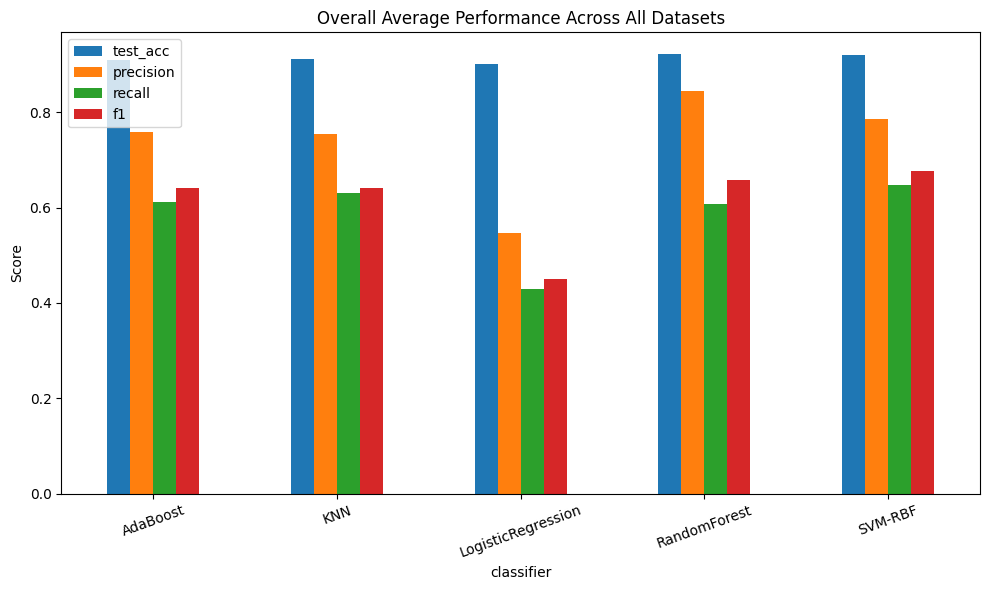

In [ ]:
i


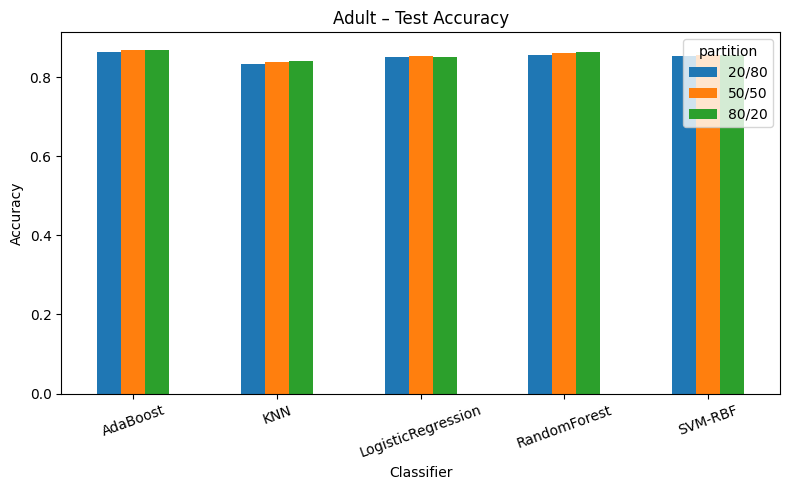

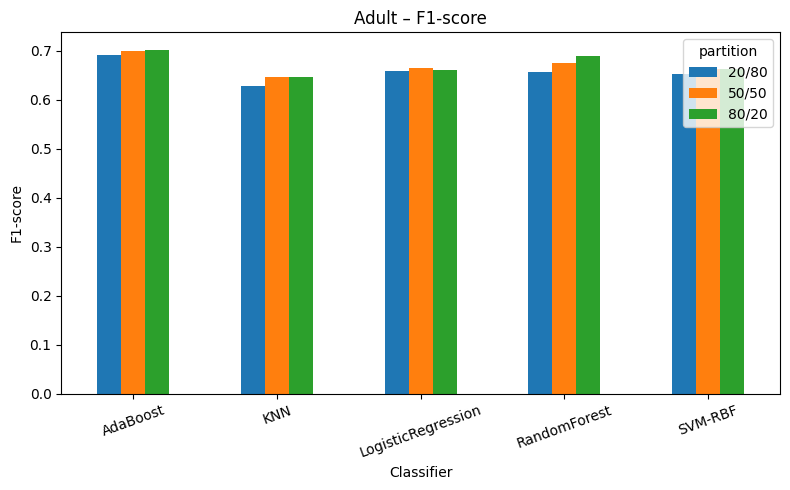

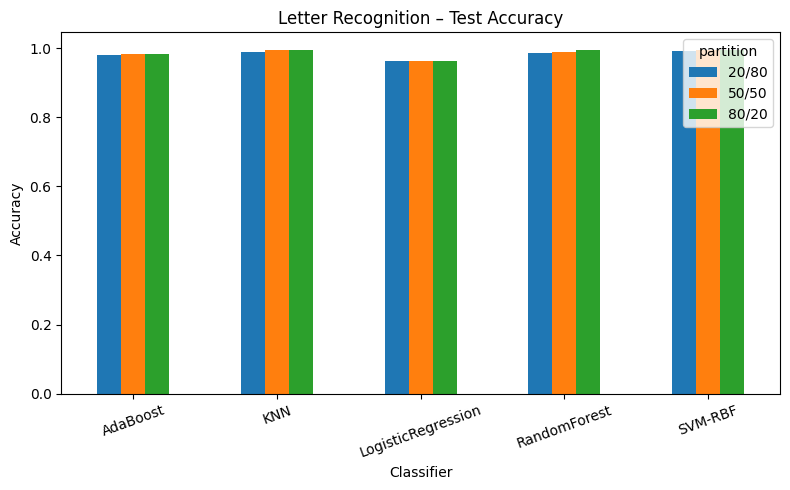

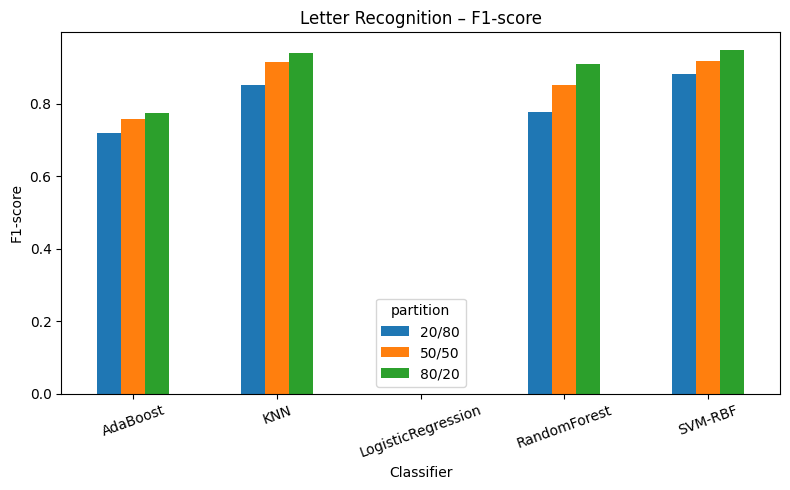

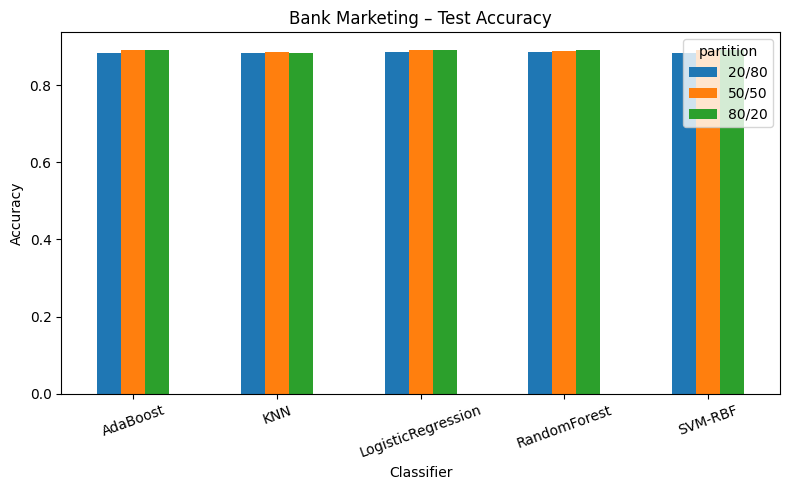

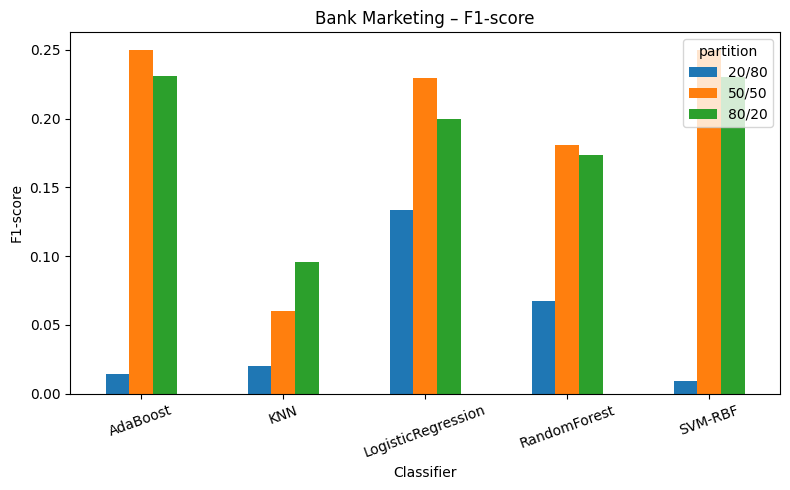

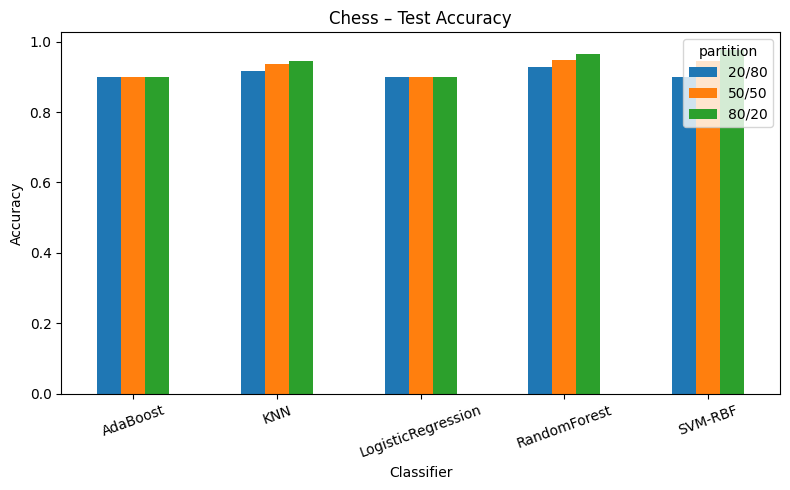

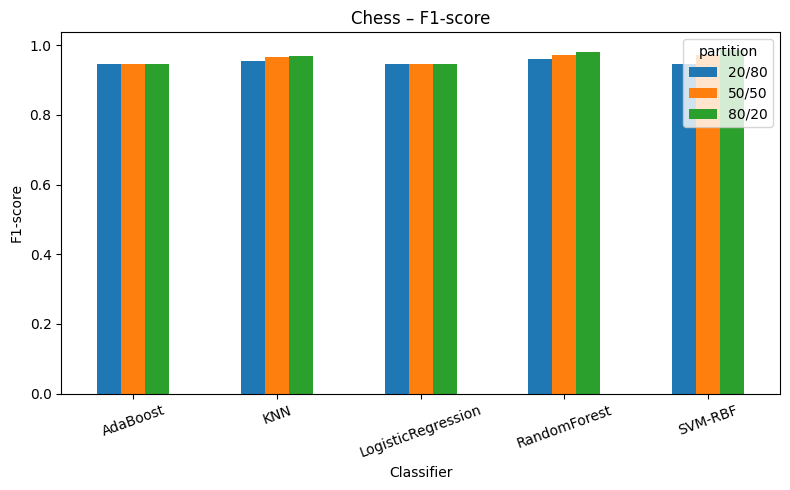

In [46]:
plot_accuracy_and_f1(summary_adult, "Adult", "adult")
plot_accuracy_and_f1(summary_letter, "Letter Recognition", "letter")
plot_accuracy_and_f1(summary_bank_marketing, "Bank Marketing", "bank")
plot_accuracy_and_f1(summary_chess, "Chess", "chess")


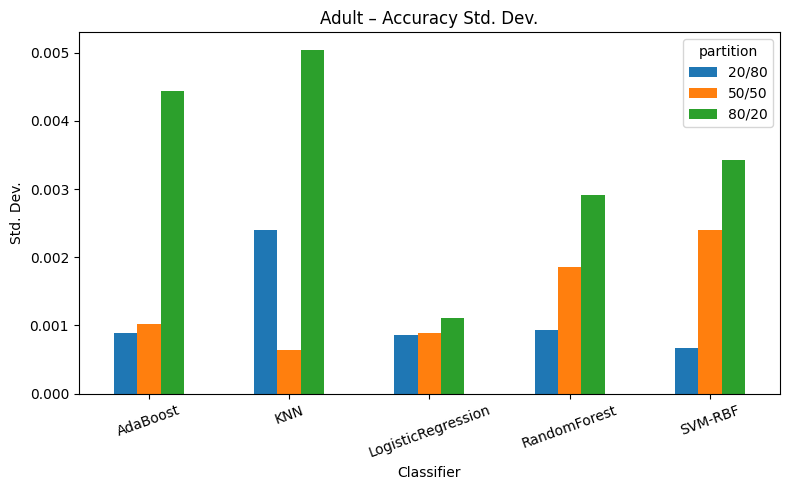

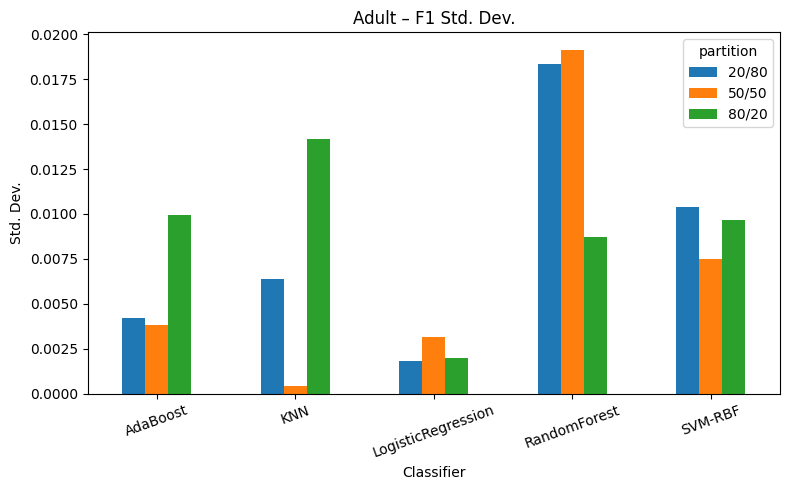

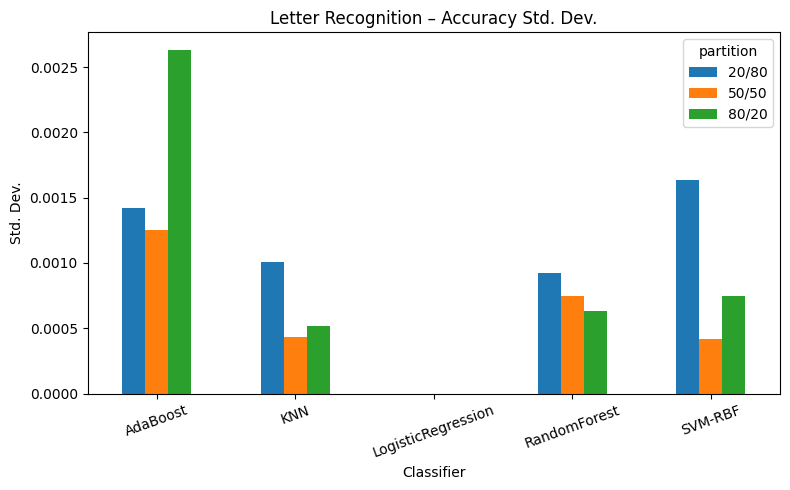

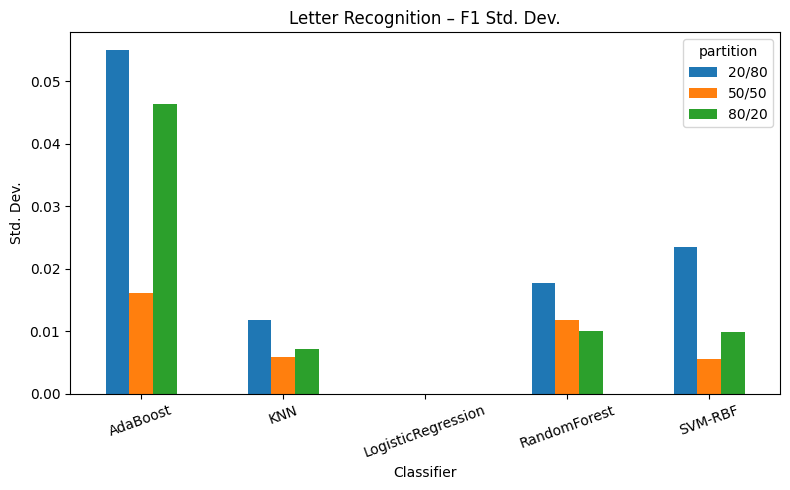

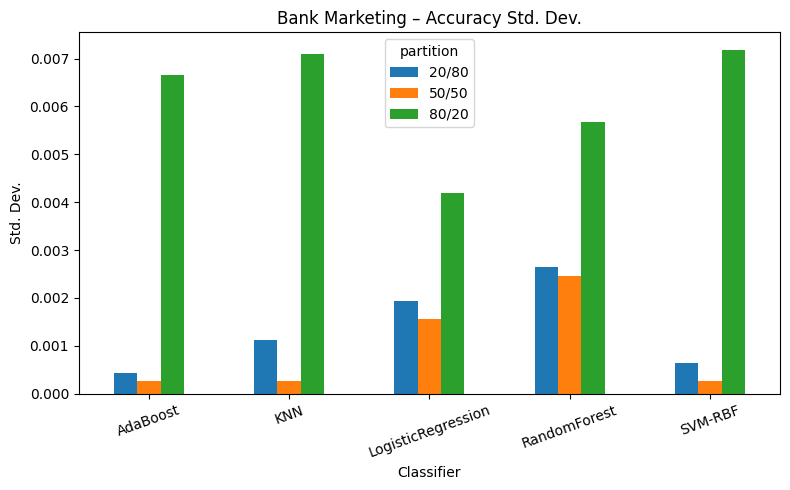

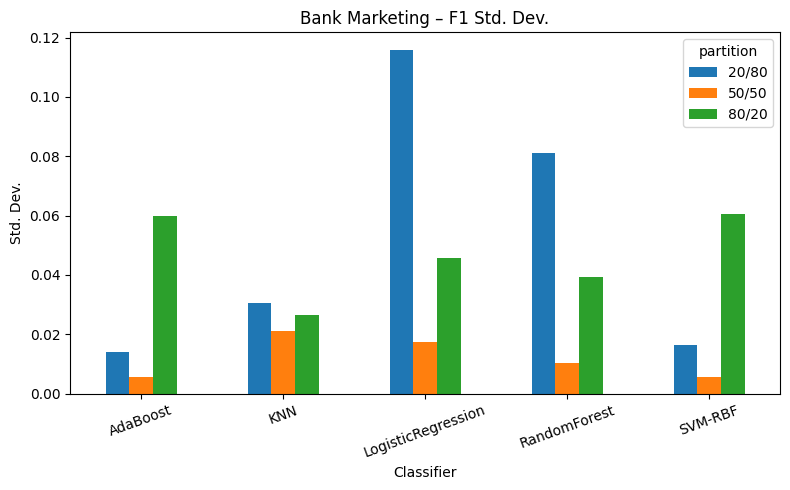

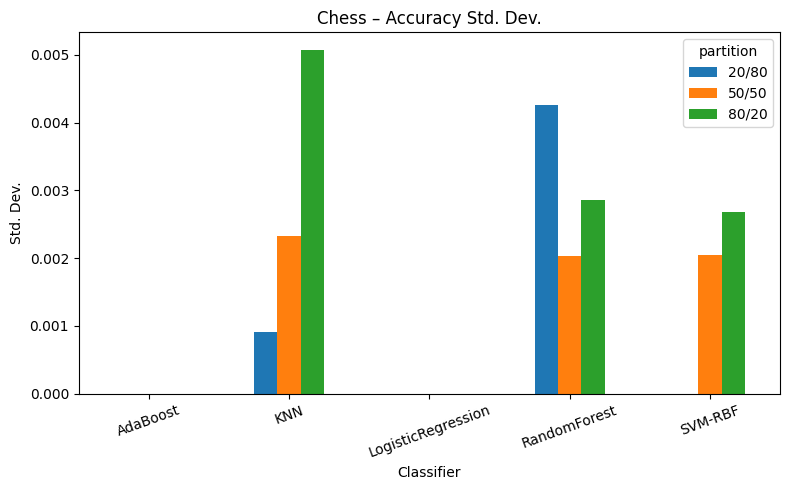

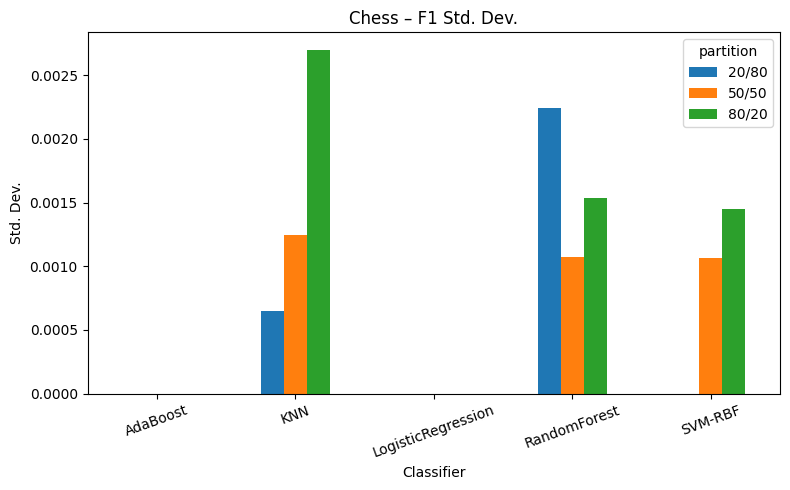

In [47]:
plot_variability(summary_adult, "Adult", "adult")
plot_variability(summary_letter, "Letter Recognition", "letter")
plot_variability(summary_bank_marketing, "Bank Marketing", "bank")
plot_variability(summary_chess, "Chess", "chess")


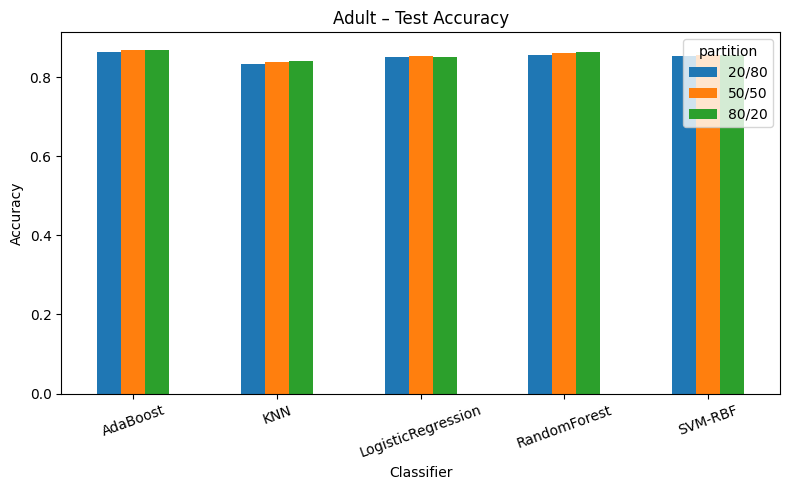

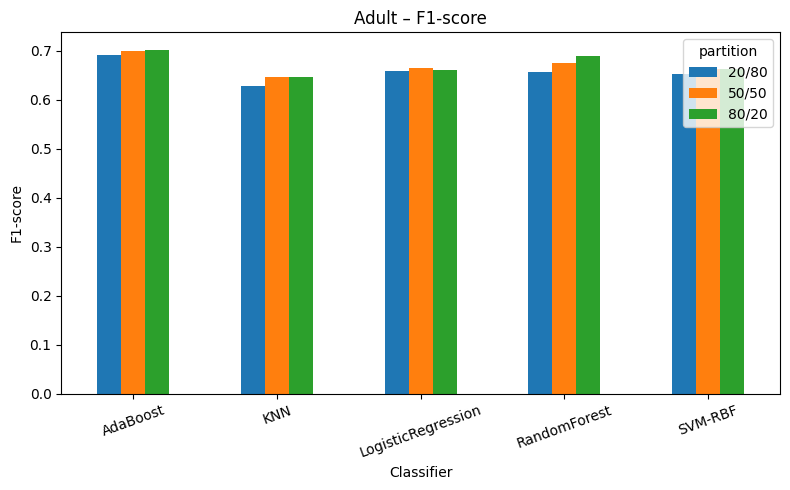

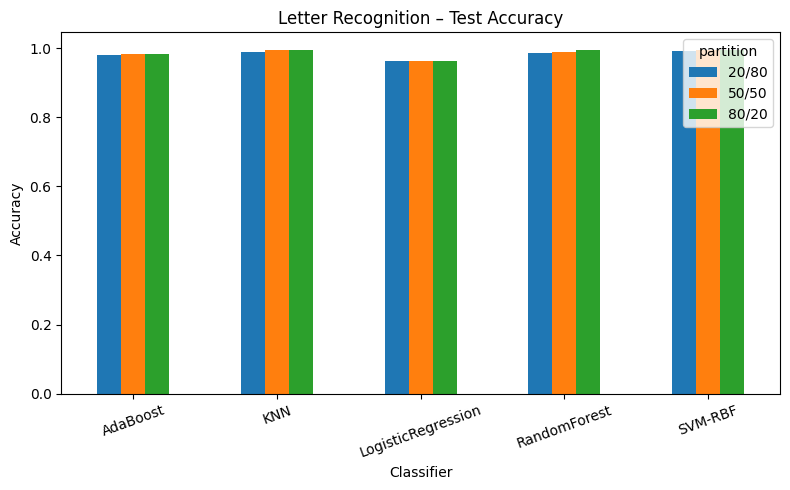

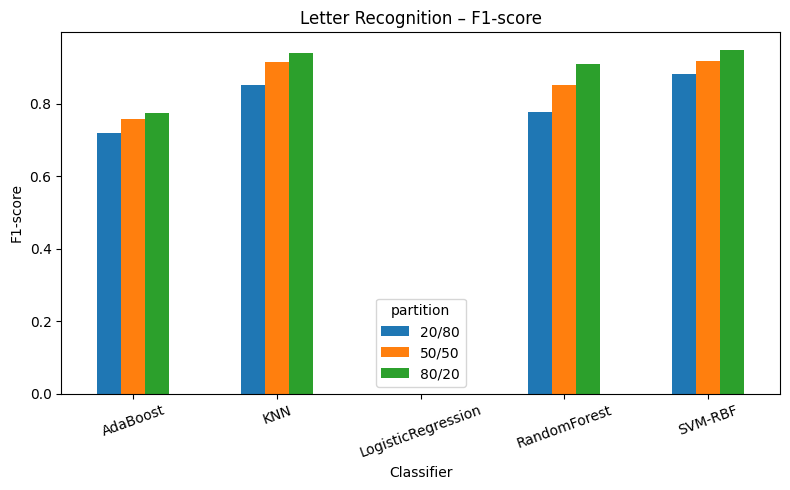

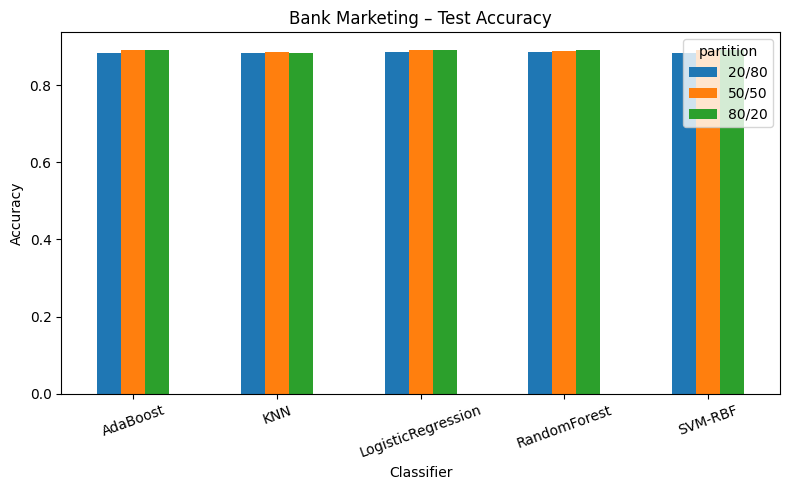

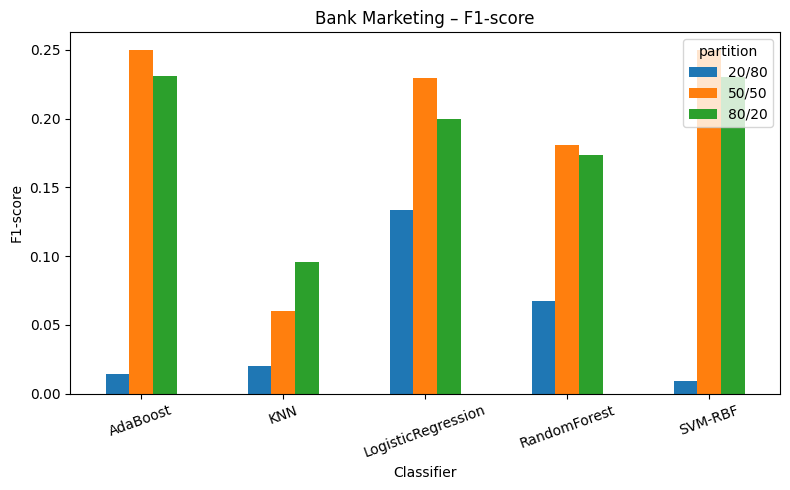

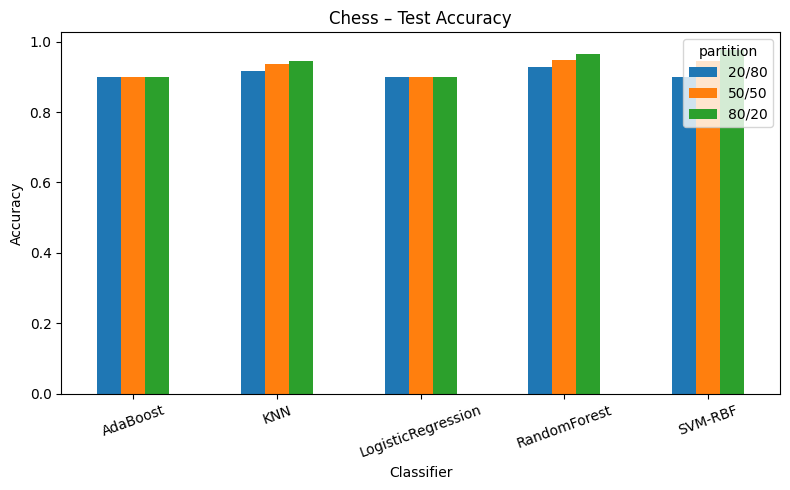

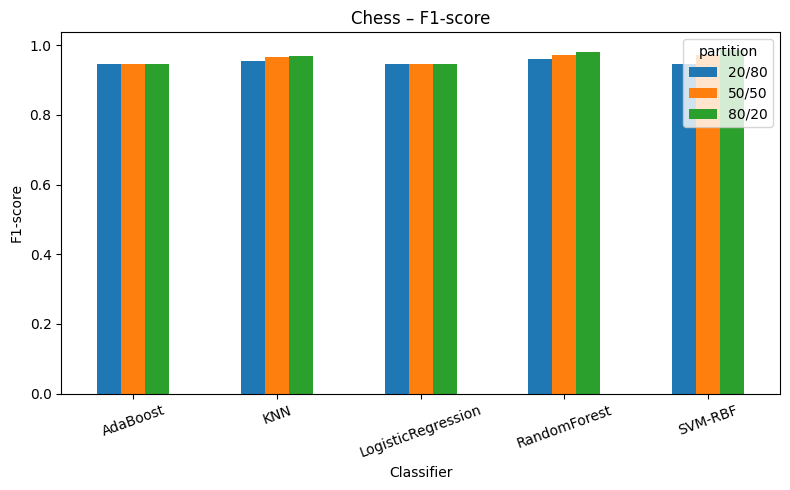

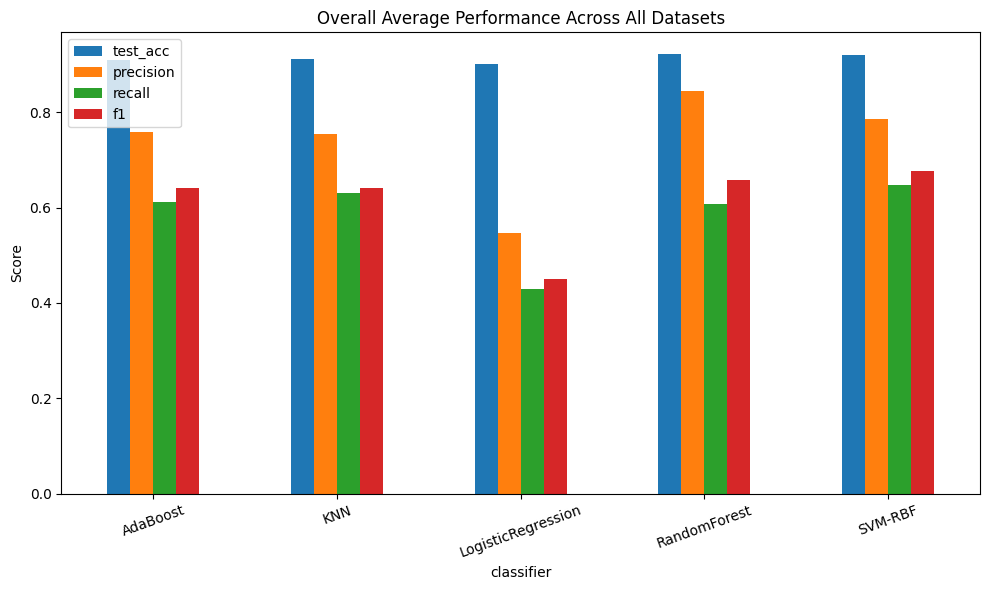

In [48]:
plot_accuracy_and_f1(summary_adult, "Adult", "adult")
plot_accuracy_and_f1(summary_letter, "Letter Recognition", "letter")
plot_accuracy_and_f1(summary_bank_marketing, "Bank Marketing", "bank")
plot_accuracy_and_f1(summary_chess, "Chess", "chess")

plot_overall_performance(overall_summary)
# (and variability plots if you want)
